<h1>Using Remote Qick</h1>


The Remote QICK Client allows QICK programs to be executed on a remote board while developing and launching experiments from a separate computer.

Install the client package and ensure that the same QICK version is available on both the PC and the board whenever possible.

Useful resources:
<ul>
  <li><a href="https://docs.qick.dev/latest/">QICK Documentation: QICK Documentation</a></li>
  <li><a href="https://github.com/openquantumhardware/qick">QICK GitHub: QICK GitHub Repository</a>
</ul>

**Connecting to the server**

In [1]:
from QickRemote import QickClient 
client = QickClient(ip_server="localhost", port=5555)

The connection is established when the client object is created.

**Retrieving the board configuration**

Before creating QICK programs, retrieve the board configuration:

In [2]:
soccfg = client.get_config()
print(soccfg)

QICK running on ZCU216, software version 0.2.286

Firmware configuration (built Mon Aug 21 11:09:34 2023):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 3 is 3_230, on JHC4
	4:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MH

C:\Users\NS2-manip\AppData\Local\miniforge3\envs\qick\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The returned object is a standard QickConfig object.

Useful documentation:
<ul>
  <li><a href="https://docs.qick.dev/latest/_autosummary/qick.qick_asm.html">QickConfig: QickConfig Documentation</a><li>
<ul>

**Creating a QICK program**

Programs are written exactly as in standard QICK.\
Example:

In [3]:
from qick.averager_program import AveragerProgram
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   
        res_ch = cfg["res_ch"]

        # set the nyquist zone
        self.declare_gen(ch=cfg["res_ch"], nqz=1)
        
        # configure the readout lengths and downconversion frequencies (ensuring it is an available DAC frequency)
        for ch in cfg["ro_chs"]:
            self.declare_readout(ch=ch, length=self.cfg["readout_length"],
                                 freq=self.cfg["pulse_freq"], gen_ch=cfg["res_ch"])

        # convert frequency to DAC frequency (ensuring it is an available ADC frequency)
        freq = self.freq2reg(cfg["pulse_freq"],gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]
        self.default_pulse_registers(ch=res_ch, freq=freq, phase=phase, gain=gain)

        style=self.cfg["pulse_style"]

        if style in ["flat_top","arb"]:
            sigma = cfg["sigma"]
            self.add_gauss(ch=res_ch, name="measure", sigma=sigma, length=sigma*5)
            
        if style == "const":
            self.set_pulse_registers(ch=res_ch, style=style, length=cfg["length"])
        elif style == "flat_top":
            # The first half of the waveform ramps up the pulse, the second half ramps down the pulse
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure", length=cfg["length"])
        elif style == "arb":
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure")
        
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        # fire the pulse
        # trigger all declared ADCs
        # pulse PMOD0_0 for a scope trigger
        # pause the tProc until readout is done
        # increment the time counter to give some time before the next measurement
        # (the syncdelay also lets the tProc get back ahead of the clock)
        self.measure(pulse_ch=self.cfg["res_ch"], 
                     adcs=self.ro_chs,
                     pins=[0], 
                     adc_trig_offset=self.cfg["adc_trig_offset"],
                     wait=True,
                     syncdelay=self.us2cycles(self.cfg["relax_delay"]))

Any base classes used by the program (for example `AveragerProgram`) must be available on the remote board where the program will be executed.

Useful references:
<ul>
  <li><a href="https://docs.qick.dev/latest/_autosummary/qick.averager_program.html">AveragerProgram: AveragerProgram Documentation</a></li>
  <li> <a href="https://github.com/openquantumhardware/qick/tree/main/qick_demos">Official examples: QICK Examples Directory</a>
</ul>



**Define your config**

In [4]:
GEN_CH = 6
RO_CH = 0

In [5]:
cfg={"res_ch":GEN_CH, # --Fixed
        "ro_chs":[RO_CH], # --Fixed
        "reps":1, # --Fixed
        "relax_delay":1.0, # --us
        "res_phase":0, #262.63764904, #  --degrees
        "pulse_style": "const", # --Fixed
        
        
        "length":soccfg.us2cycles(2.0)/2, # [Clock ticks]
        # Try varying length from 10-100 clock ticks
        
        "readout_length":soccfg.us2cycles(2), # [Clock ticks]
        # Try varying readout_length from 50-1000 clock ticks

        "pulse_gain":500//2, # [DAC units]
        # Try varying pulse_gain from 500 to 30000 DAC units

        "pulse_freq": 2930.000250, # [MHz]
        # In this program the signal is up and downconverted digitally so you won't see any frequency
        # components in the I/Q traces below. But since the signal gain depends on frequency, 
        # if you lower pulse_freq you will see an increased gain.

        "adc_trig_offset":soccfg.us2cycles(0.0), # [Clock ticks]
        # Try varying adc_trig_offset from 100 to 220 clock ticks

        "soft_avgs":100
        # Try varying soft_avgs from 1 to 200 averages

       }

**Submitting a measurement**

In [6]:
from QickRemote import QickJob 

In [7]:
job = client.submit(prog=LoopbackProgram, config=cfg, nom_programme="my_job" )

Job 'my_job' ajouté à la file.


The function immediately returns a QickJob object :

In [9]:
print(job)

QickJob('my_job', status='done')


**Waiting for completion**

The simplest workflow is the function wait. This method blocks until the measurement is finished and then returns the acquisition result.\
The default refresh period is 1 second, but it can be modified using the `refresh` parameter:

In [10]:
iq_data1=job.wait(refresh=0.5)

my_job terminé (0 s dont 0 s de mesure)


**Checking job status**

If you do not want to block execution, you can simply check the status of the job.\
The possible status are `queued` `running` `done` `failed` `cancelled`


In [11]:
print(job.status())

done


**Retrieving the result**

After having checked that a job has completed, you can retrieve the result with `job.result()`

If the job in unfinished, an exception is raised.

If the job failed, the full traceback generated on the board is returned.

In [16]:
iq_data=job.result()

**Displaying detailed information**

`job.print_info()` prints the informations avaliable and you can also acces raw information with it.
`client.jobs` gives you acces to all previous jobs information realised in the current session.

In [12]:
job.print_info()

Job : my_job
Status : done
Temps total : 0 s
Temps mesure : 0 s



{'status': 'done',
 'result': array([[[ 0.2 ,  0.14, -0.05, ...,  0.04, -0.11, -0.07],
         [ 0.22, -0.05, -0.2 , ...,  0.1 , -0.08, -0.13]]]),
 'temps total': 0,
 'durée taitement': 0}

In [13]:
info=job.print_info()
print(info)

Job : my_job
Status : done
Temps total : 0 s
Temps mesure : 0 s

{'status': 'done', 'result': array([[[ 0.2 ,  0.14, -0.05, ...,  0.04, -0.11, -0.07],
        [ 0.22, -0.05, -0.2 , ...,  0.1 , -0.08, -0.13]]]), 'temps total': 0, 'durée taitement': 0}


**Cancelling a job**

If a job has not yet started, it can be removed from the queue with `job.cancel()`\
Even if the canceled job is finished, cancelling the job allows you to re-use its name. (of course you can only cancel your own job but cannot pick a name taken by somebody else)

In [14]:
job_to_delete = client.submit(prog=LoopbackProgram, config=cfg, nom_programme="my_job")
job_to_delete.cancel()
print(job_to_delete in client.jobs)
print(client.jobs)

Le nom 'my_job' était déjà utilisé. Le job a été renommé en 'job_e50b6830'.
False
[QickJob('my_job', status='done')]


**Example of use**

If you do not cancel your job, you can plot it :)

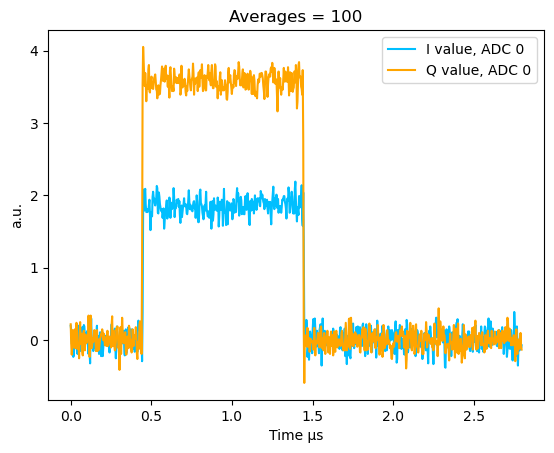

In [17]:
import numpy as np
import matplotlib.pyplot as plt
iq_list=iq_data
theta0=0 # degree      phase indep freq
tau=0 # 165.2735890    
# Plot results.
comp=(iq_list[:,0]+1j*iq_list[:,1])*np.exp(-2*1j*np.pi*cfg['pulse_freq']*(tau)-2*1j*np.pi*theta0/360)
time=[x/307.200 for x in list(range(len(comp[0])))] # time is in us
plt.figure(1)
plt.plot(time,np.real(comp[0]), label="I value, ADC %d"%(cfg['ro_chs'][0]),color="deepskyblue")
plt.plot(time,np.imag(comp[0]), label="Q value, ADC %d"%(cfg['ro_chs'][0]),color="orange")
    #plt.plot(np.abs(iq[0]+1j*iq[1]), label="mag, ADC %d"%(config['ro_chs'][ii]))
plt.ylabel("a.u.")
plt.xlabel("Time µs")
plt.title("Averages = " + str(cfg["soft_avgs"]))
plt.legend();



**Multiple jobs**

Several measurements may be submitted and added to the queue

In [18]:
prog1=prog2=prog3=LoopbackProgram
cfg1=cfg2=cfg3=cfg
job1 = client.submit(prog1, cfg1, "job1")
job2 = client.submit(prog2, cfg2,"job2")
job3 = client.submit(prog3, cfg3,"job3")

Job 'job1' ajouté à la file.
Job 'job2' ajouté à la file.
Job 'job3' ajouté à la file.


**Closing a session**

`client.close()` cancels all jobs, cuts the communication with the server.\
Please use it at the end of each session.

**Monitoring all jobs**

`client.check_all()` prints the status of every job submitted by the current client. It also returns a dictionnary with the result of done jobs you have realised on your session associated with the name of the job.

In [18]:
jobs=client.check_all()
print(jobs)


4
État des jobs :

job_ff194f08 -> terminé
job_d95c65d6 -> terminé
job_ccb64877 -> terminé
job_f21e17f4 -> terminé
{'job_ff194f08': array([[[ 0.06, -0.07, -0.15, ...,  0.09, -0.07, -0.18],
        [-0.11, -0.22, -0.07, ..., -0.1 , -0.04, -0.05]]]), 'job_d95c65d6': array([[[ 0.05,  0.18,  0.02, ...,  0.3 ,  0.2 ,  0.02],
        [ 0.04, -0.08,  0.01, ...,  0.11,  0.03,  0.12]]]), 'job_ccb64877': array([[[-0.18,  0.05,  0.04, ..., -0.11, -0.13, -0.14],
        [-0.02,  0.14,  0.06, ..., -0.21, -0.1 ,  0.07]]]), 'job_f21e17f4': array([[[-0.12, -0.17, -0.26, ..., -0.11,  0.  ,  0.06],
        [ 0.16,  0.11, -0.01, ...,  0.01, -0.05,  0.06]]])}
4


**Waiting for all jobs**

`client.wait_all(refresh)` is equivalent of `job.wait(refresh)` but for all submitted jobs that have not been yet retrieved. It waits until every job that have not been yet retrieved has reached a final state.\
The default value for `refresh` is 1s\
It returns a dictionnary with the result of done jobs you have realised on your session associated with the name of the job.

In [21]:
finished = client.wait_all()
print(finished)

job_8ef568cf -> terminé (0 s)
job_583f5e2c -> terminé (0 s)
job_af737bfa -> terminé (1 s)
{'job_8ef568cf': array([[[-0.06,  0.03, -0.01, ...,  0.18,  0.1 , -0.02],
        [-0.11, -0.1 ,  0.02, ...,  0.12, -0.01, -0.08]]]), 'job_583f5e2c': array([[[ 0.19,  0.12,  0.31, ..., -0.06, -0.15, -0.06],
        [-0.06, -0.05,  0.05, ..., -0.04, -0.02, -0.02]]]), 'job_af737bfa': array([[[ 0.  , -0.11,  0.07, ..., -0.04,  0.08,  0.07],
        [-0.13, -0.21, -0.21, ...,  0.08, -0.01, -0.01]]])}
